In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("sales_data.db")

cursor = conn.cursor()

In [3]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [4]:
sales_data = [
    ("Laptop", 5, 50000),
    ("Mouse", 20, 500),
    ("Keyboard", 15, 1200),
    ("Monitor", 8, 9000),
    ("Laptop", 3, 50000),
    ("Mouse", 10, 500),
    ("Keyboard", 5, 1200),
    ("Monitor", 2, 9000)
]

cursor.executemany(
    "INSERT INTO sales(product, quantity, price) VALUES (?, ?, ?)",
    sales_data
)

conn.commit()

In [5]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product;
"""

In [6]:
df = pd.read_sql_query(query, conn)

In [7]:
print(df)

    product  total_qty   revenue
0  Keyboard         20   24000.0
1    Laptop          8  400000.0
2   Monitor         10   90000.0
3     Mouse         30   15000.0


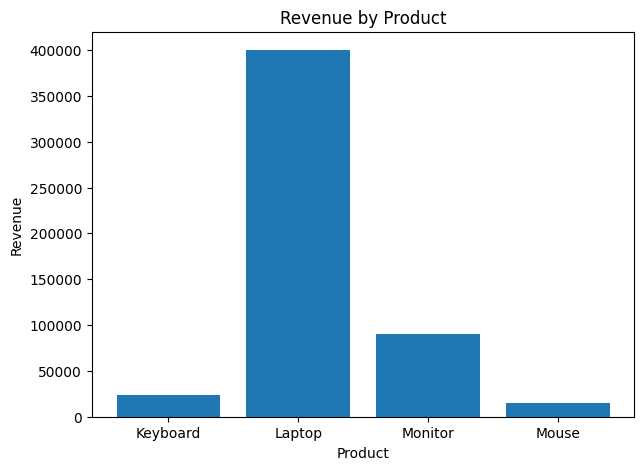

In [8]:
plt.figure(figsize=(7,5))

plt.bar(df["product"], df["revenue"])

plt.title("Revenue by Product")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.savefig("sales_chart.png")

plt.show()

In [ ]:
conn.close()